# Classification task overview
This notebook trains and evaluates XGBoost classifiers on scRNA-seq derived features to predict COVID-19 severity categories.
It filters PCR-positive samples, compares binary and multiclass target encodings, and reports model performance with confusion matrices and classification metrics.
The workflow includes data loading, preprocessing, class balancing checks, feature selection, model training, and visualization of results.

# Classification task 
## XGBoost


In [1]:
import os

# Check current directory
print(os.getcwd())

# Search for the file
for root, dirs, files in os.walk('.'):
    for f in files:
        if 'scvi' in f.lower():
            print(os.path.join(root, f))

/Users/ingridkjaerulffjensen/code/Applied-Machine-Learning-Final-Project/Ingrid
./scVI_draft.ipynb
./scVI2.ipynb
./scVI_draft2.ipynb
./MLP_scVI.ipynb
./Regression_XGBoost_MLP_scVI.ipynb
./plots_images/scVI_loss_curves.png
./plots_images/75epochs_scVI_latent_states.png
./subdata/scvi_latent_75ep.csv
./subdata/scvi_latent_representation_full.csv
./subdata/scvi_latent_representation_full.parquet
./subdata/scvi_umap_75ep.csv


In [2]:
print(os.getcwd())

/Users/ingridkjaerulffjensen/code/Applied-Machine-Learning-Final-Project/Ingrid


In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('subdata/scvi_latent_75ep.csv', index_col=0)

# Filter to PCR positive
df_pos = df[df['PCR_Status'] == 'positive'].copy()

# Check patient-level WHO distribution
participant_who = df_pos.groupby('Participant')['WHO_score'].first()
print("Patient-level WHO score distribution:")
print(participant_who.value_counts().sort_index())
print(f"\nTotal participants: {len(participant_who)}")

# Preview class sizes for both schemes
print("\n--- 2-class scheme (mild 0-3 vs severe 5-8, exclude 4) ---")
mild   = (participant_who <= 3).sum()
severe = (participant_who >= 5).sum()
excl   = (participant_who == 4).sum()
print(f"  Mild:     {mild}")
print(f"  Severe:   {severe}")
print(f"  Excluded: {excl}")

print("\n--- 3-class scheme (mild 0-3, moderate 4-5, severe 6-8) ---")
mild3 = (participant_who <= 3).sum()
mod3  = (participant_who.isin([4,5])).sum()
sev3  = (participant_who >= 6).sum()
print(f"  Mild:     {mild3}")
print(f"  Moderate: {mod3}")
print(f"  Severe:   {sev3}")

Patient-level WHO score distribution:
WHO_score
0     1
1     4
2     1
3     9
4    17
5     8
6     3
7     5
8    23
Name: count, dtype: int64

Total participants: 71

--- 2-class scheme (mild 0-3 vs severe 5-8, exclude 4) ---
  Mild:     15
  Severe:   39
  Excluded: 17

--- 3-class scheme (mild 0-3, moderate 4-5, severe 6-8) ---
  Mild:     15
  Moderate: 25
  Severe:   31


## 2 Classes: LETS GOOO

In [5]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, f1_score, 
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(27)

# ── Filter to PCR positive ────────────────────────────────────────────────────
df_pos = df[df['PCR_Status'] == 'positive'].copy()
print(f"PCR positive cells: {len(df_pos)}")
print(f"PCR positive participants: {df_pos['Participant'].nunique()}")

PCR positive cells: 37982
PCR positive participants: 71


In [6]:
# ── Class definitions ─────────────────────────────────────────────────────────
# Change N_CLASSES to switch between 2 and 3 class schemes
N_CLASSES = 2  # set to 3 for 3-class

def assign_class(who_score, n_classes):
    if n_classes == 2:
        if who_score <= 3:
            return 'mild'
        else:
            return 'severe'
    else:
        if who_score <= 3:
            return 'mild'
        elif who_score <= 5:
            return 'moderate'
        else:
            return 'severe'

df_pos['severity_class'] = df_pos['WHO_score'].apply(
    lambda x: assign_class(x, N_CLASSES)
)

# ── Class distribution ────────────────────────────────────────────────────────
print(f"\n{N_CLASSES}-class scheme:")
participant_classes = df_pos.groupby('Participant')['severity_class'].first()
print("Participant level:")
print(participant_classes.value_counts())
print("\nCell level:")
print(df_pos['severity_class'].value_counts())

# ── Class imbalance ratio for XGBoost ────────────────────────────────────────
if N_CLASSES == 2:
    n_severe = (participant_classes == 'severe').sum()
    n_mild   = (participant_classes == 'mild').sum()
    scale_pos_weight = n_severe / n_mild
    print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")


2-class scheme:
Participant level:
severity_class
severe    56
mild      15
Name: count, dtype: int64

Cell level:
severity_class
severe    29519
mild       8463
Name: count, dtype: int64

scale_pos_weight: 3.73


In [7]:
# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
df_pos['label'] = le.fit_transform(df_pos['severity_class'])
print("Class encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

# ── Feature columns ───────────────────────────────────────────────────────────
feature_cols = [f"scVI_{i+1}" for i in range(20)]

# ── Cell type encoding ────────────────────────────────────────────────────────
le_ct = LabelEncoder()
df_pos['cell_type_encoded'] = le_ct.fit_transform(df_pos['cell_type'])

# ── Helper: plot confusion matrix ─────────────────────────────────────────────
def plot_confusion_matrix(cm, classes, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ── Helper: print fold results ────────────────────────────────────────────────
def summarize_results(fold_results, model_name):
    df_r = pd.DataFrame(fold_results)
    print(f"\nCV Summary ({model_name}):")
    print(f"  Balanced Acc: {df_r['bal_acc'].mean():.3f} ± {df_r['bal_acc'].std():.3f}")
    print(f"  F1 (macro):   {df_r['f1_macro'].mean():.3f} ± {df_r['f1_macro'].std():.3f}")
    return df_r

Class encoding:
  0: mild
  1: severe


In [8]:
# ── XGBoost CV function ───────────────────────────────────────────────────────
def run_xgb_classification(X, y, groups, cv, model_name,
                            n_classes=2, scale_pos_weight=1.0):
    fold_results = []
    all_y_test   = []
    all_y_pred   = []

    objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'
    eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups) 
                                                  if groups is not None 
                                                  else cv.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        params = dict(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=27,
            n_jobs=2,
            tree_method='hist',
            objective=objective,
            eval_metric=eval_metric
        )

        if n_classes == 2:
            params['scale_pos_weight'] = scale_pos_weight
        else:
            params['num_class'] = n_classes

        model_fold = xgb.XGBClassifier(**params)
        model_fold.fit(X_train, y_train, verbose=False)
        y_pred = model_fold.predict(X_test)

        bal_acc  = balanced_accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')

        fold_results.append({
            'fold': fold+1, 
            'bal_acc': bal_acc, 
            'f1_macro': f1_macro,
            'n_test': len(y_test)
        })
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"  Fold {fold+1}: Bal.Acc={bal_acc:.3f} | F1={f1_macro:.3f} | "
              f"test={len(y_test)}")

    results_df = summarize_results(fold_results, model_name)

    # Confusion matrix across all folds
    cm = confusion_matrix(all_y_test, all_y_pred)
    plot_confusion_matrix(cm, le.classes_, f'Confusion Matrix — {model_name}')

    # Classification report
    print(f"\nClassification Report ({model_name}):")
    print(classification_report(all_y_test, all_y_pred, 
                                target_names=le.classes_))

    return results_df, np.array(all_y_test), np.array(all_y_pred)

In [9]:
# ── Participant-level aggregation (reused across models 3 and 4) ──────────────
cell_types = sorted(df_pos['cell_type'].unique().tolist())

participant_rows = []
for participant, group in df_pos.groupby('Participant'):
    row = {'Participant': participant}
    row['severity_class'] = group['severity_class'].iloc[0]
    row['label']          = group['label'].iloc[0]
    row['WHO_score']      = group['WHO_score'].iloc[0]

    # Per cell type mean latent
    for ct in cell_types:
        ct_cells = group[group['cell_type'] == ct]
        for f in feature_cols:
            row[f"{ct}_{f}"] = ct_cells[f].mean() if len(ct_cells) > 0 else 0.0

    # Cell type proportions
    total = len(group)
    for ct in cell_types:
        row[f"prop_{ct}"] = (group['cell_type'] == ct).sum() / total

    participant_rows.append(row)

participant_agg_df = pd.DataFrame(participant_rows).set_index('Participant')

latent_features = [f"{ct}_{f}" for ct in cell_types for f in feature_cols]
prop_features   = [f"prop_{ct}" for ct in cell_types]
all_agg_features = latent_features + prop_features

# Simple mean aggregation for model 3
participant_mean_df = df_pos.groupby('Participant')[feature_cols].mean()
participant_mean_df['label'] = df_pos.groupby('Participant')['label'].first()

print(f"Participant aggregation done: {len(participant_agg_df)} participants")
print(f"Features — latent: {len(latent_features)} | props: {len(prop_features)}")

Participant aggregation done: 71 participants
Features — latent: 260 | props: 13


Model 1: Cell-level latent only
  Fold 1: Bal.Acc=0.533 | F1=0.514 | test=7413
  Fold 2: Bal.Acc=0.503 | F1=0.426 | test=8191
  Fold 3: Bal.Acc=0.606 | F1=0.648 | test=9918
  Fold 4: Bal.Acc=0.521 | F1=0.436 | test=7588
  Fold 5: Bal.Acc=0.506 | F1=0.483 | test=4872

CV Summary (Cell latent only):
  Balanced Acc: 0.534 ± 0.042
  F1 (macro):   0.501 ± 0.089


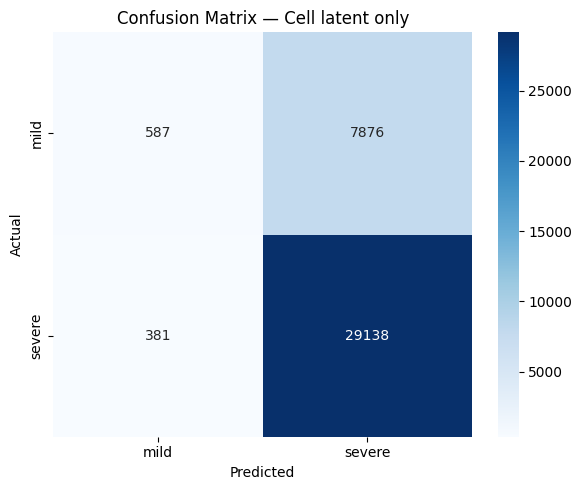


Classification Report (Cell latent only):
              precision    recall  f1-score   support

        mild       0.61      0.07      0.12      8463
      severe       0.79      0.99      0.88     29519

    accuracy                           0.78     37982
   macro avg       0.70      0.53      0.50     37982
weighted avg       0.75      0.78      0.71     37982



In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1: Cell-level latent only
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 1: Cell-level latent only")

X_m1     = df_pos[feature_cols].values.astype(np.float32)
y_m1     = df_pos['label'].values
groups_m1 = df_pos['Participant'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=27)

res1, yt1, yp1 = run_xgb_classification(
    X_m1, y_m1, groups_m1, sgkf,
    model_name='Cell latent only',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0
)

Model 2: Cell-level latent + cell type
  Fold 1: Bal.Acc=0.533 | F1=0.516 | test=7413
  Fold 2: Bal.Acc=0.504 | F1=0.428 | test=8191
  Fold 3: Bal.Acc=0.613 | F1=0.661 | test=9918
  Fold 4: Bal.Acc=0.525 | F1=0.443 | test=7588
  Fold 5: Bal.Acc=0.505 | F1=0.482 | test=4872

CV Summary (Cell latent + cell type):
  Balanced Acc: 0.536 ± 0.045
  F1 (macro):   0.506 ± 0.093


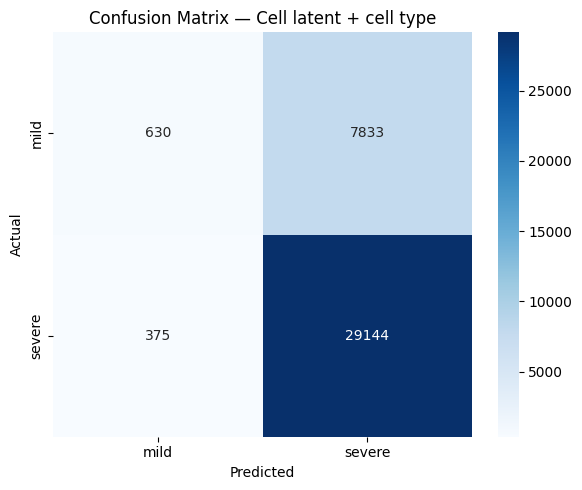


Classification Report (Cell latent + cell type):
              precision    recall  f1-score   support

        mild       0.63      0.07      0.13      8463
      severe       0.79      0.99      0.88     29519

    accuracy                           0.78     37982
   macro avg       0.71      0.53      0.50     37982
weighted avg       0.75      0.78      0.71     37982



In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2: Cell-level latent + cell type
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 2: Cell-level latent + cell type")

X_m2 = df_pos[feature_cols + ['cell_type_encoded']].values.astype(np.float32)
y_m2 = y_m1

res2, yt2, yp2 = run_xgb_classification(
    X_m2, y_m2, groups_m1, sgkf,
    model_name='Cell latent + cell type',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0
)

Model 3: Participant mean latent
  Fold 1: Bal.Acc=0.500 | F1=0.444 | test=15
  Fold 2: Bal.Acc=0.500 | F1=0.440 | test=14
  Fold 3: Bal.Acc=0.500 | F1=0.440 | test=14
  Fold 4: Bal.Acc=0.500 | F1=0.440 | test=14
  Fold 5: Bal.Acc=0.621 | F1=0.635 | test=14

CV Summary (Participant mean latent):
  Balanced Acc: 0.524 ± 0.054
  F1 (macro):   0.480 ± 0.087


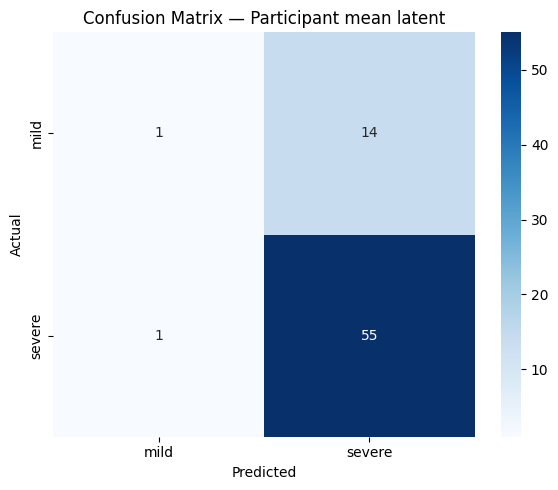


Classification Report (Participant mean latent):
              precision    recall  f1-score   support

        mild       0.50      0.07      0.12        15
      severe       0.80      0.98      0.88        56

    accuracy                           0.79        71
   macro avg       0.65      0.52      0.50        71
weighted avg       0.73      0.79      0.72        71



In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3: Participant mean latent
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 3: Participant mean latent")

X_m3 = participant_mean_df[feature_cols].values.astype(np.float32)
y_m3 = participant_mean_df['label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

res3, yt3, yp3 = run_xgb_classification(
    X_m3, y_m3, None, skf,
    model_name='Participant mean latent',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0
)

Model 4: Participant per-celltype + composition
  Fold 1: Bal.Acc=0.500 | F1=0.444 | test=15
  Fold 2: Bal.Acc=0.500 | F1=0.440 | test=14
  Fold 3: Bal.Acc=0.667 | F1=0.708 | test=14
  Fold 4: Bal.Acc=0.455 | F1=0.417 | test=14
  Fold 5: Bal.Acc=0.500 | F1=0.440 | test=14

CV Summary (Participant per-celltype + props):
  Balanced Acc: 0.524 ± 0.082
  F1 (macro):   0.490 ± 0.123


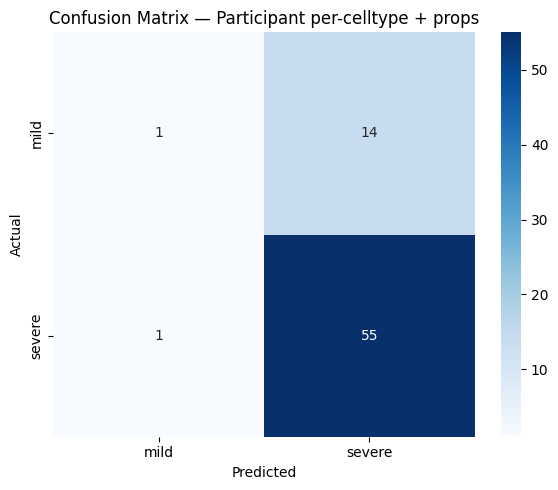


Classification Report (Participant per-celltype + props):
              precision    recall  f1-score   support

        mild       0.50      0.07      0.12        15
      severe       0.80      0.98      0.88        56

    accuracy                           0.79        71
   macro avg       0.65      0.52      0.50        71
weighted avg       0.73      0.79      0.72        71



In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 4: Participant per-celltype + composition
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 4: Participant per-celltype + composition")

X_m4 = participant_agg_df[all_agg_features].values.astype(np.float32)
y_m4 = participant_agg_df['label'].values

res4, yt4, yp4 = run_xgb_classification(
    X_m4, y_m4, None, skf,
    model_name='Participant per-celltype + props',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0,
)

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# FULL COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"FULL COMPARISON — {N_CLASSES}-class XGBoost Classification")
print(f"\n{'Model':<35} {'Bal.Acc':>10} {'F1 macro':>10}")
for name, res in [
    ('Cell latent only',             res1),
    ('Cell latent + cell type',      res2),
    ('Participant mean latent',      res3),
    ('Participant per-celltype+props', res4)
]:
    print(f"  {name:<33} {res['bal_acc'].mean():>10.3f} {res['f1_macro'].mean():>10.3f}")


FULL COMPARISON — 2-class XGBoost Classification

Model                                  Bal.Acc   F1 macro
  Cell latent only                       0.534      0.501
  Cell latent + cell type                0.536      0.506
  Participant mean latent                0.524      0.480
  Participant per-celltype+props         0.524      0.490


# 3 Classes 

In [15]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, f1_score, 
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(27)

# ── Filter to PCR positive ────────────────────────────────────────────────────
df_pos = df[df['PCR_Status'] == 'positive'].copy()
print(f"PCR positive cells: {len(df_pos)}")
print(f"PCR positive participants: {df_pos['Participant'].nunique()}")

PCR positive cells: 37982
PCR positive participants: 71


In [16]:
# ── Class definitions ─────────────────────────────────────────────────────────
# Change N_CLASSES to switch between 2 and 3 class schemes
N_CLASSES = 3  # set to 3 for 3-class

def assign_class(who_score, n_classes):
    if n_classes == 2:
        if who_score <= 3:
            return 'mild'
        else:
            return 'severe'
    else:
        if who_score <= 3:
            return 'mild'
        elif who_score <= 5:
            return 'moderate'
        else:
            return 'severe'

df_pos['severity_class'] = df_pos['WHO_score'].apply(
    lambda x: assign_class(x, N_CLASSES)
)

# ── Class distribution ────────────────────────────────────────────────────────
print(f"\n{N_CLASSES}-class scheme:")
participant_classes = df_pos.groupby('Participant')['severity_class'].first()
print("Participant level:")
print(participant_classes.value_counts())
print("\nCell level:")
print(df_pos['severity_class'].value_counts())

# ── Class imbalance ratio for XGBoost ────────────────────────────────────────
if N_CLASSES == 2:
    n_severe = (participant_classes == 'severe').sum()
    n_mild   = (participant_classes == 'mild').sum()
    scale_pos_weight = n_severe / n_mild
    print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")


3-class scheme:
Participant level:
severity_class
severe      31
moderate    25
mild        15
Name: count, dtype: int64

Cell level:
severity_class
severe      16559
moderate    12960
mild         8463
Name: count, dtype: int64


In [17]:
# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
df_pos['label'] = le.fit_transform(df_pos['severity_class'])
print("Class encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

# ── Feature columns ───────────────────────────────────────────────────────────
feature_cols = [f"scVI_{i+1}" for i in range(20)]

# ── Cell type encoding ────────────────────────────────────────────────────────
le_ct = LabelEncoder()
df_pos['cell_type_encoded'] = le_ct.fit_transform(df_pos['cell_type'])

# ── Helper: plot confusion matrix ─────────────────────────────────────────────
def plot_confusion_matrix(cm, classes, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ── Helper: print fold results ────────────────────────────────────────────────
def summarize_results(fold_results, model_name):
    df_r = pd.DataFrame(fold_results)
    print(f"\nCV Summary ({model_name}):")
    print(f"  Balanced Acc: {df_r['bal_acc'].mean():.3f} ± {df_r['bal_acc'].std():.3f}")
    print(f"  F1 (macro):   {df_r['f1_macro'].mean():.3f} ± {df_r['f1_macro'].std():.3f}")
    return df_r

Class encoding:
  0: mild
  1: moderate
  2: severe


In [18]:
# ── XGBoost CV function ───────────────────────────────────────────────────────
def run_xgb_classification(X, y, groups, cv, model_name,
                            n_classes=2, scale_pos_weight=1.0):
    fold_results = []
    all_y_test   = []
    all_y_pred   = []

    objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'
    eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups) 
                                                  if groups is not None 
                                                  else cv.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        params = dict(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=27,
            n_jobs=2,
            tree_method='hist',
            objective=objective,
            eval_metric=eval_metric
        )

        if n_classes == 2:
            params['scale_pos_weight'] = scale_pos_weight
        else:
            params['num_class'] = n_classes

        model_fold = xgb.XGBClassifier(**params)
        model_fold.fit(X_train, y_train, verbose=False)
        y_pred = model_fold.predict(X_test)

        bal_acc  = balanced_accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro')

        fold_results.append({
            'fold': fold+1, 
            'bal_acc': bal_acc, 
            'f1_macro': f1_macro,
            'n_test': len(y_test)
        })
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"  Fold {fold+1}: Bal.Acc={bal_acc:.3f} | F1={f1_macro:.3f} | "
              f"test={len(y_test)}")

    results_df = summarize_results(fold_results, model_name)

    # Confusion matrix across all folds
    cm = confusion_matrix(all_y_test, all_y_pred)
    plot_confusion_matrix(cm, le.classes_, f'Confusion Matrix — {model_name}')

    # Classification report
    print(f"\nClassification Report ({model_name}):")
    print(classification_report(all_y_test, all_y_pred, 
                                target_names=le.classes_))

    return results_df, np.array(all_y_test), np.array(all_y_pred)

In [19]:
# ── Participant-level aggregation (reused across models 3 and 4) ──────────────
cell_types = sorted(df_pos['cell_type'].unique().tolist())

participant_rows = []
for participant, group in df_pos.groupby('Participant'):
    row = {'Participant': participant}
    row['severity_class'] = group['severity_class'].iloc[0]
    row['label']          = group['label'].iloc[0]
    row['WHO_score']      = group['WHO_score'].iloc[0]

    # Per cell type mean latent
    for ct in cell_types:
        ct_cells = group[group['cell_type'] == ct]
        for f in feature_cols:
            row[f"{ct}_{f}"] = ct_cells[f].mean() if len(ct_cells) > 0 else 0.0

    # Cell type proportions
    total = len(group)
    for ct in cell_types:
        row[f"prop_{ct}"] = (group['cell_type'] == ct).sum() / total

    participant_rows.append(row)

participant_agg_df = pd.DataFrame(participant_rows).set_index('Participant')

latent_features = [f"{ct}_{f}" for ct in cell_types for f in feature_cols]
prop_features   = [f"prop_{ct}" for ct in cell_types]
all_agg_features = latent_features + prop_features

# Simple mean aggregation for model 3
participant_mean_df = df_pos.groupby('Participant')[feature_cols].mean()
participant_mean_df['label'] = df_pos.groupby('Participant')['label'].first()

print(f"Participant aggregation done: {len(participant_agg_df)} participants")
print(f"Features — latent: {len(latent_features)} | props: {len(prop_features)}")

Participant aggregation done: 71 participants
Features — latent: 260 | props: 13


Model 1: Cell-level latent only
  Fold 1: Bal.Acc=0.397 | F1=0.376 | test=6041
  Fold 2: Bal.Acc=0.380 | F1=0.378 | test=9009
  Fold 3: Bal.Acc=0.482 | F1=0.402 | test=5449
  Fold 4: Bal.Acc=0.496 | F1=0.489 | test=11520
  Fold 5: Bal.Acc=0.449 | F1=0.380 | test=5963

CV Summary (Cell latent only):
  Balanced Acc: 0.441 ± 0.051
  F1 (macro):   0.405 ± 0.048


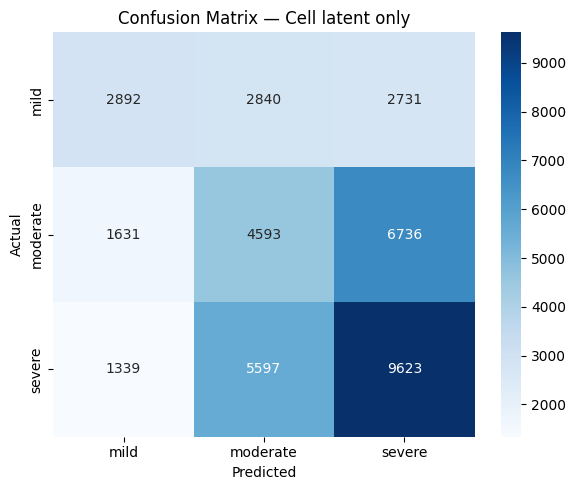


Classification Report (Cell latent only):
              precision    recall  f1-score   support

        mild       0.49      0.34      0.40      8463
    moderate       0.35      0.35      0.35     12960
      severe       0.50      0.58      0.54     16559

    accuracy                           0.45     37982
   macro avg       0.45      0.43      0.43     37982
weighted avg       0.45      0.45      0.45     37982



In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1: Cell-level latent only
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 1: Cell-level latent only")

X_m1     = df_pos[feature_cols].values.astype(np.float32)
y_m1     = df_pos['label'].values
groups_m1 = df_pos['Participant'].values

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=27)

res1, yt1, yp1 = run_xgb_classification(
    X_m1, y_m1, groups_m1, sgkf,
    model_name='Cell latent only',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0
)

Model 2: Cell-level latent + cell type
  Fold 1: Bal.Acc=0.399 | F1=0.379 | test=6041
  Fold 2: Bal.Acc=0.385 | F1=0.385 | test=9009
  Fold 3: Bal.Acc=0.486 | F1=0.404 | test=5449
  Fold 4: Bal.Acc=0.507 | F1=0.500 | test=11520
  Fold 5: Bal.Acc=0.454 | F1=0.393 | test=5963

CV Summary (Cell latent + cell type):
  Balanced Acc: 0.446 ± 0.053
  F1 (macro):   0.412 ± 0.050


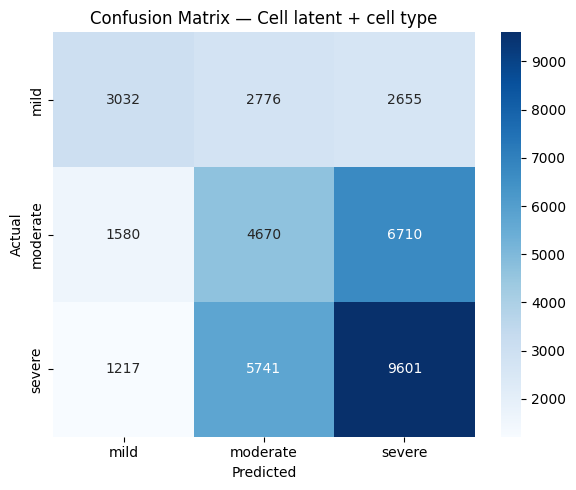


Classification Report (Cell latent + cell type):
              precision    recall  f1-score   support

        mild       0.52      0.36      0.42      8463
    moderate       0.35      0.36      0.36     12960
      severe       0.51      0.58      0.54     16559

    accuracy                           0.46     37982
   macro avg       0.46      0.43      0.44     37982
weighted avg       0.46      0.46      0.45     37982



In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2: Cell-level latent + cell type
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 2: Cell-level latent + cell type")

X_m2 = df_pos[feature_cols + ['cell_type_encoded']].values.astype(np.float32)
y_m2 = y_m1

res2, yt2, yp2 = run_xgb_classification(
    X_m2, y_m2, groups_m1, sgkf,
    model_name='Cell latent + cell type',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0
)

Model 3: Participant mean latent
  Fold 1: Bal.Acc=0.416 | F1=0.403 | test=15
  Fold 2: Bal.Acc=0.289 | F1=0.289 | test=14
  Fold 3: Bal.Acc=0.522 | F1=0.524 | test=14
  Fold 4: Bal.Acc=0.467 | F1=0.398 | test=14
  Fold 5: Bal.Acc=0.311 | F1=0.278 | test=14

CV Summary (Participant mean latent):
  Balanced Acc: 0.401 ± 0.100
  F1 (macro):   0.378 ± 0.100


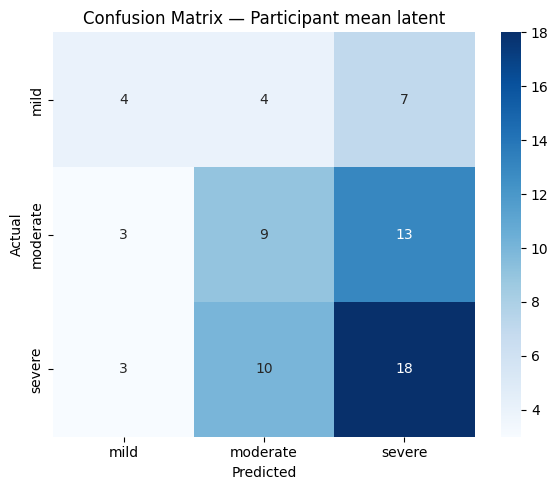


Classification Report (Participant mean latent):
              precision    recall  f1-score   support

        mild       0.40      0.27      0.32        15
    moderate       0.39      0.36      0.37        25
      severe       0.47      0.58      0.52        31

    accuracy                           0.44        71
   macro avg       0.42      0.40      0.41        71
weighted avg       0.43      0.44      0.43        71



In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3: Participant mean latent
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 3: Participant mean latent")

X_m3 = participant_mean_df[feature_cols].values.astype(np.float32)
y_m3 = participant_mean_df['label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

res3, yt3, yp3 = run_xgb_classification(
    X_m3, y_m3, None, skf,
    model_name='Participant mean latent',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0
)

Model 4: Participant per-celltype + composition
  Fold 1: Bal.Acc=0.502 | F1=0.526 | test=15
  Fold 2: Bal.Acc=0.400 | F1=0.385 | test=14
  Fold 3: Bal.Acc=0.467 | F1=0.493 | test=14
  Fold 4: Bal.Acc=0.444 | F1=0.444 | test=14
  Fold 5: Bal.Acc=0.656 | F1=0.666 | test=14

CV Summary (Participant per-celltype + props):
  Balanced Acc: 0.494 ± 0.098
  F1 (macro):   0.503 ± 0.105


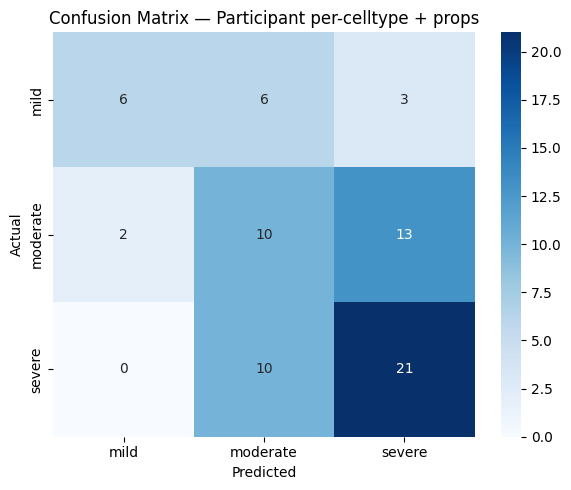


Classification Report (Participant per-celltype + props):
              precision    recall  f1-score   support

        mild       0.75      0.40      0.52        15
    moderate       0.38      0.40      0.39        25
      severe       0.57      0.68      0.62        31

    accuracy                           0.52        71
   macro avg       0.57      0.49      0.51        71
weighted avg       0.54      0.52      0.52        71



In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 4: Participant per-celltype + composition
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("Model 4: Participant per-celltype + composition")

X_m4 = participant_agg_df[all_agg_features].values.astype(np.float32)
y_m4 = participant_agg_df['label'].values

res4, yt4, yp4 = run_xgb_classification(
    X_m4, y_m4, None, skf,
    model_name='Participant per-celltype + props',
    n_classes=N_CLASSES,
    scale_pos_weight=scale_pos_weight if N_CLASSES == 2 else 1.0,
)

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# FULL COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"FULL COMPARISON — {N_CLASSES}-class XGBoost Classification")
print(f"\n{'Model':<35} {'Bal.Acc':>10} {'F1 macro':>10}")
for name, res in [
    ('Cell latent only',             res1),
    ('Cell latent + cell type',      res2),
    ('Participant mean latent',      res3),
    ('Participant per-celltype+props', res4)
]:
    print(f"  {name:<33} {res['bal_acc'].mean():>10.3f} {res['f1_macro'].mean():>10.3f}")


FULL COMPARISON — 3-class XGBoost Classification

Model                                  Bal.Acc   F1 macro
  Cell latent only                       0.441      0.405
  Cell latent + cell type                0.446      0.412
  Participant mean latent                0.401      0.378
  Participant per-celltype+props         0.494      0.503


Accuracy (and why plain accuracy is misleading here)
Plain accuracy = percentage of correct predictions. Sounds simple, but it's deceptive with imbalanced classes. In our 2-class case with 15 mild and 56 severe patients, a model that always predicts severe would be right 56/71 = 79% of the time — without learning anything at all.

Balanced Accuracy
Balanced accuracy fixes this by calculating accuracy separately for each class and averaging:

Accuracy on mild patients: how many mild did we correctly identify?
Accuracy on severe patients: how many severe did we correctly identify?
Balanced accuracy = average of these two

For a random model this gives 0.5 for 2 classes and 0.333 for 3 classes — regardless of class imbalance. So:

Our 2-class model: 0.536 → only 3.6% above random
Our 3-class model: 0.494 → 16% above random (0.333 baseline)

F1 Score
F1 combines two things for each class:

Precision — of all the patients we predicted as mild, how many actually were mild?
Recall — of all the actual mild patients, how many did we correctly identify?

F1 = harmonic mean of precision and recall. It penalizes models that are good at one but bad at the other.
Macro F1 averages F1 across all classes equally — so the small mild class counts just as much as the large severe class. This makes it a good metric for imbalanced problems.

Random baseline: ~0.33 for 2 classes (with imbalance), ~0.33 for 3 classes
Our 2-class best: 0.506 → modest
Our 3-class best: 0.503 → similar

### Feature importance model 4 (3 classes)


In [25]:
# Retrain model 4 classification (3-class) and save fold models
fold_models_cls4 = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_m4, y_m4)):
    X_train, X_test = X_m4[train_idx], X_m4[test_idx]
    y_train, y_test = y_m4[train_idx], y_m4[test_idx]

    model_fold = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=27,
        n_jobs=2, tree_method='hist',
        objective='multi:softmax', num_class=3,
        eval_metric='mlogloss'
    )
    model_fold.fit(X_train, y_train, verbose=False)
    fold_models_cls4.append(model_fold)
    print(f"Fold {fold+1} done")

# Extract importance
importance_cls = fold_models_cls4[-1].get_booster().get_score(importance_type='gain')

imp_cls_df = pd.DataFrame({
    'feature': list(importance_cls.keys()),
    'importance': list(importance_cls.values())
}).sort_values('importance', ascending=False)

print(f"\nTotal features with non-zero importance: {len(imp_cls_df)}")
print(imp_cls_df.head(20).to_string())

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

Total features with non-zero importance: 238
    feature  importance
5        f5    2.456828
14      f19    2.442491
218    f249    2.278822
53      f61    2.132170
72      f84    1.940655
122    f142    1.929545
59      f70    1.910952
91     f109    1.903014
174    f202    1.879163
187    f215    1.826811
153    f177    1.782321
184    f212    1.637795
113    f132    1.618471
21      f27    1.596116
100    f119    1.586444
40      f46    1.558236
175    f203    1.549799
73      f85    1.544342
168    f196    1.528943
67      f79    1.527505


In [26]:
# Assign proper feature names and extract importance
fold_models_cls4[-1].get_booster().feature_names = all_agg_features

importance_cls = fold_models_cls4[-1].get_booster().get_score(importance_type='gain')

imp_cls_df = pd.DataFrame({
    'feature': list(importance_cls.keys()),
    'importance': list(importance_cls.values())
}).sort_values('importance', ascending=False)

print(f"Total features with non-zero importance: {len(imp_cls_df)}")
print(imp_cls_df.head(20).to_string())

Total features with non-zero importance: 238
                   feature  importance
5            B_Cell_scVI_6    2.456828
14          B_Cell_scVI_20    2.442491
218         T_Cell_scVI_10    2.278822
53        Dendritic_scVI_2    2.132170
72     Deuterosomal_scVI_5    1.940655
122         MT-high_scVI_3    1.929545
59       Dendritic_scVI_11    1.910952
91          Goblet_scVI_10    1.903014
174       Secretory_scVI_3    1.879163
187      Secretory_scVI_16    1.826811
153     Macrophage_scVI_18    1.782321
184      Secretory_scVI_13    1.637795
113      Ionocytes_scVI_13    1.618471
21            Basal_scVI_8    1.596116
100         Goblet_scVI_20    1.586444
40         Ciliated_scVI_7    1.558236
175       Secretory_scVI_4    1.549799
73     Deuterosomal_scVI_6    1.544342
168  SARSCoV2-high_scVI_17    1.528943
67       Dendritic_scVI_20    1.527505


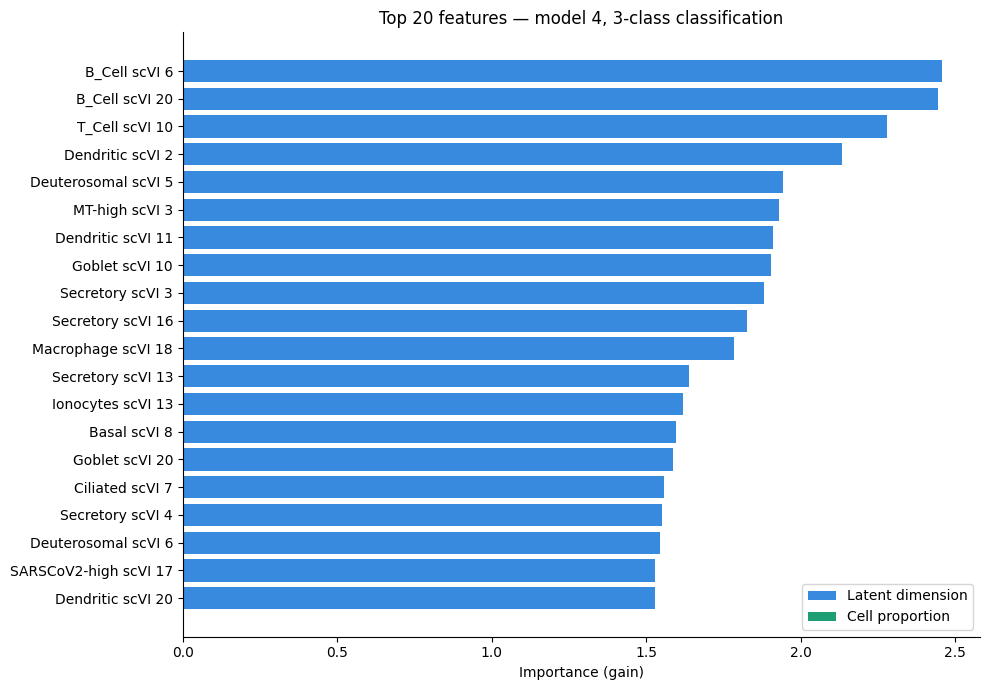

In [27]:
# ── Feature importance plot — classification model 4 (3-class) ────────────────
import matplotlib.pyplot as plt

top20_cls = imp_cls_df.head(20).sort_values('importance', ascending=True)

colors = ['#1D9E75' if f.startswith('prop_') else '#378ADD' 
          for f in top20_cls['feature']]

# Clean up feature names for display
def clean_name(f):
    if f.startswith('prop_'):
        return 'prop ' + f.replace('prop_', '')
    elif '_scVI_' in f:
        parts = f.split('_scVI_')
        return parts[0] + ' scVI ' + parts[1]
    return f

top20_cls['label'] = top20_cls['feature'].apply(clean_name)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20_cls['label'], top20_cls['importance'], color=colors)
ax.set_xlabel('Importance (gain)')
ax.set_title('Top 20 features — model 4, 3-class classification')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#378ADD', label='Latent dimension'),
    Patch(facecolor='#1D9E75', label='Cell proportion')
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
# Find all variables containing fold models
[v for v in dir() if 'fold' in v.lower() or 'model' in v.lower()]

['StratifiedGroupKFold',
 'StratifiedKFold',
 'fold',
 'fold_models_cls4',
 'model_fold']

In [46]:
# Extract importance from last fold of classification model 4
importance_cls = fold_models_cls4[-1].get_booster().get_score(importance_type='gain')

imp_cls_df = pd.DataFrame({
    'feature': list(importance_cls.keys()),
    'importance': list(importance_cls.values())
}).sort_values('importance', ascending=False)

print(f"Total features with non-zero importance: {len(imp_cls_df)}")
print(imp_cls_df.head(20).to_string())

NameError: name 'fold_models_cls4' is not defined

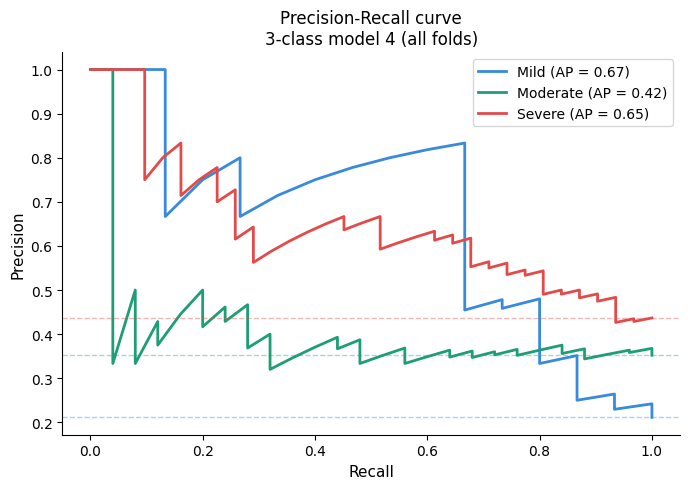

/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:821: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/model_selection/_validation.py", line 810, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 353, in _score
    y_pred = method_caller(estimator, "predict", X)
  File "/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_scorer.py", line 86, in _cached_call
    result, _ = _get_respo

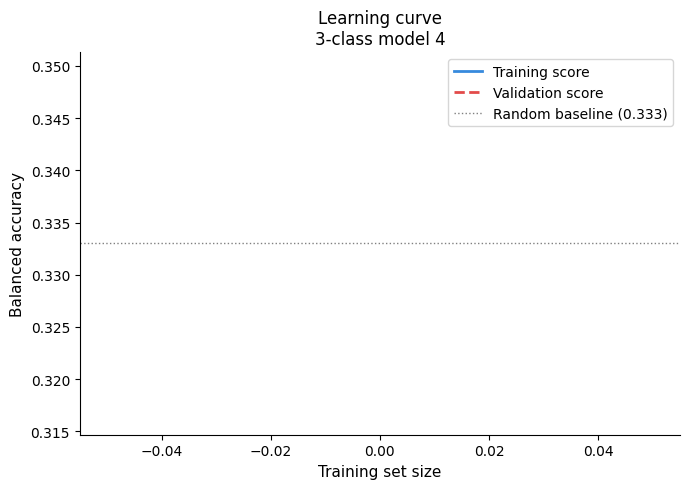

In [29]:
#!?!
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import StratifiedKFold, learning_curve
import matplotlib.pyplot as plt
import numpy as np

# ── Precision-Recall Curve ────────────────────────────────────────────────────
# Collect predictions across folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)
class_names = ['Mild', 'Moderate', 'Severe']
n_classes = 3

all_y_test_bin = []
all_y_prob     = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_m4, y_m4)):
    X_train, X_test = X_m4[train_idx], X_m4[test_idx]
    y_train, y_test = y_m4[train_idx], y_m4[test_idx]

    model_fold = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=27,
        n_jobs=2, tree_method='hist',
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss'
    )
    model_fold.fit(X_train, y_train, verbose=False)

    y_prob = model_fold.predict_proba(X_test)
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    all_y_test_bin.append(y_test_bin)
    all_y_prob.append(y_prob)

all_y_test_bin = np.vstack(all_y_test_bin)
all_y_prob     = np.vstack(all_y_prob)

# ── Plot precision-recall ─────────────────────────────────────────────────────
colors = ['#378ADD', '#1D9E75', '#E24B4A']

fig, ax = plt.subplots(figsize=(7, 5))

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(
        all_y_test_bin[:, i], all_y_prob[:, i]
    )
    ap = average_precision_score(all_y_test_bin[:, i], all_y_prob[:, i])
    ax.plot(recall, precision, color=color, linewidth=2,
            label=f'{cls_name} (AP = {ap:.2f})')

    # Baseline for this class
    baseline = all_y_test_bin[:, i].mean()
    ax.axhline(baseline, color=color, linewidth=1,
               linestyle='--', alpha=0.4)

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall curve\n3-class model 4 (all folds)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Learning Curve ────────────────────────────────────────────────────────────
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrap XGBoost for sklearn learning_curve compatibility
class XGBWrapper(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.model = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=27,
            n_jobs=2, tree_method='hist',
            objective='multi:softprob', num_class=3,
            eval_metric='mlogloss'
        )
        self.model.fit(X, y, verbose=False)
        return self
    def predict(self, X):
        return self.model.predict(X)
    def score(self, X, y):
        return balanced_accuracy_score(y, self.predict(X))

train_sizes, train_scores, test_scores = learning_curve(
    XGBWrapper(), X_m4, y_m4,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=27),
    train_sizes=np.linspace(0.2, 1.0, 8),
    scoring='balanced_accuracy',
    n_jobs=2
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(train_sizes, train_mean, color='#378ADD', linewidth=2, label='Training score')
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='#378ADD')

ax.plot(train_sizes, test_mean, color='#E24B4A', linewidth=2,
        linestyle='--', label='Validation score')
ax.fill_between(train_sizes, test_mean - test_std,
                test_mean + test_std, alpha=0.15, color='#E24B4A')

ax.axhline(0.333, color='gray', linewidth=1, linestyle=':',
           label='Random baseline (0.333)')

ax.set_xlabel('Training set size', fontsize=11)
ax.set_ylabel('Balanced accuracy', fontsize=11)
ax.set_title('Learning curve\n3-class model 4', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Permutation test for the best 2-class and 3-class model

In [32]:
# ── Rebuild 2-class variables ─────────────────────────────────────────────────
df_pos['severity_2class'] = df_pos['WHO_score'].apply(
    lambda x: 'mild' if x <= 3 else 'severe'
)
le_2 = LabelEncoder()
df_pos['label_2class'] = le_2.fit_transform(df_pos['severity_2class'])

n_severe = (df_pos.groupby('Participant')['label_2class'].first() == 1).sum()
n_mild   = (df_pos.groupby('Participant')['label_2class'].first() == 0).sum()
scale_pos_weight_2 = n_severe / n_mild

X_2class  = df_pos[feature_cols + ['cell_type_encoded']].values.astype(np.float32)
y_2class  = df_pos['label_2class'].values
groups_2  = df_pos['Participant'].values

# ── Rebuild 3-class variables ─────────────────────────────────────────────────
def assign_3class(who):
    if who <= 3:   return 0  # mild
    elif who <= 5: return 1  # moderate
    else:          return 2  # severe

participant_agg_df['label_3class'] = participant_agg_df['WHO_score'].apply(assign_3class)
X_3class = participant_agg_df[all_agg_features].values.astype(np.float32)
y_3class = participant_agg_df['label_3class'].values

print("2-class distribution:")
print(pd.Series(y_2class).value_counts())
print(f"scale_pos_weight: {scale_pos_weight_2:.2f}")
print("\n3-class distribution:")
print(pd.Series(y_3class).value_counts())

2-class distribution:
1    29519
0     8463
Name: count, dtype: int64
scale_pos_weight: 3.73

3-class distribution:
2    31
1    25
0    15
Name: count, dtype: int64


Running permutation test — 2-class (Cell latent + cell type)...
  10/500 done...


/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  20/500 done...
  30/500 done...


/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  40/500 done...


...

  470/500 done...


/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  480/500 done...
  490/500 done...


/Users/ingridkjaerulffjensen/envs/mlenv2/lib/python3.8/site-packages/sklearn/metrics/_classification.py:2399: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  500/500 done...

2-class permutation test:
  Observed Bal.Acc:  0.536
  Permutation mean:  0.511 ± 0.032
  p-value:           1.16e-01
  Better than random: No

Running permutation test — 3-class (Participant per-celltype+props)...
  100/500 done...
  200/500 done...
  300/500 done...
  400/500 done...
  500/500 done...

3-class permutation test:
  Observed Bal.Acc:  0.494
  Permutation mean:  0.332 ± 0.062
  p-value:           1.60e-02
  Better than random: Yes


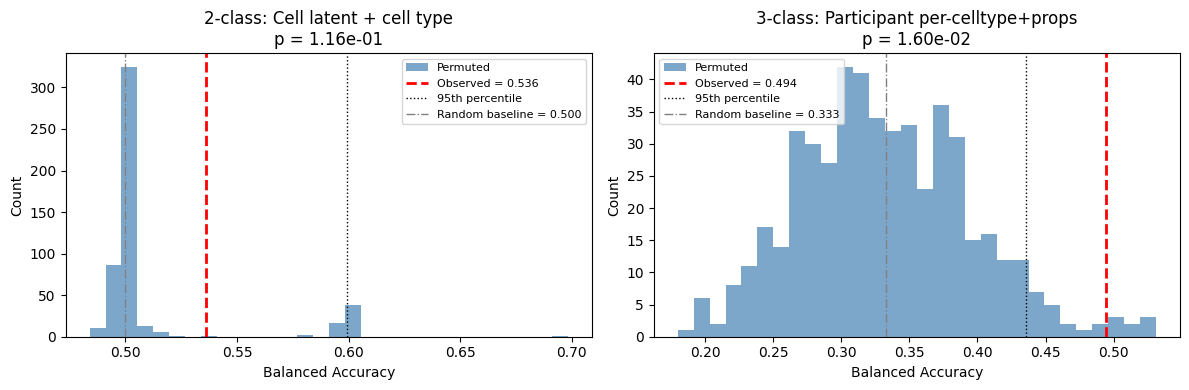

In [34]:
# ── Permutation test — 2-class (Cell latent + cell type) ─────────────────────
print("Running permutation test — 2-class (Cell latent + cell type)...")

n_permutations = 500
perm_scores_2class = []
sgkf_perm = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=27)

for perm in range(n_permutations):
    # Shuffle labels at participant level to preserve group structure
    participants_unique  = df_pos['Participant'].unique()
    participant_label_map = df_pos.groupby('Participant')['label_2class'].first().to_dict()
    shuffled_map = dict(zip(
        participants_unique,
        np.random.permutation(list(participant_label_map.values()))
    ))
    y_shuffled = df_pos['Participant'].map(shuffled_map).values

    fold_scores = []
    for train_idx, test_idx in sgkf_perm.split(X_2class, y_shuffled, groups_2):
        X_train, X_test = X_2class[train_idx], X_2class[test_idx]
        y_train, y_test = y_shuffled[train_idx], y_shuffled[test_idx]

        model_perm = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=27,
            n_jobs=2, tree_method='hist',
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight_2,
            eval_metric='logloss'
        )
        model_perm.fit(X_train, y_train, verbose=False)
        y_pred = model_perm.predict(X_test)
        fold_scores.append(balanced_accuracy_score(y_test, y_pred))

    perm_scores_2class.append(np.mean(fold_scores))
    if (perm + 1) % 10 == 0:
        print(f"  {perm+1}/{n_permutations} done...")

observed_2class    = 0.536  # from earlier results
perm_scores_2class = np.array(perm_scores_2class)
p_value_2class     = (perm_scores_2class >= observed_2class).mean()

print(f"\n2-class permutation test:")
print(f"  Observed Bal.Acc:  {observed_2class:.3f}")
print(f"  Permutation mean:  {perm_scores_2class.mean():.3f} ± {perm_scores_2class.std():.3f}")
if p_value_2class == 0:
    print(f"  p-value:           < {1/n_permutations:.2e}")
else:
    print(f"  p-value:           {p_value_2class:.2e}")
print(f"  Better than random: {'Yes' if p_value_2class < 0.05 else 'No'}")

# ── Permutation test — 3-class (Participant per-celltype+props) ───────────────
print("\nRunning permutation test — 3-class (Participant per-celltype+props)...")

perm_scores_3class = []
skf_perm = StratifiedKFold(n_splits=5, shuffle=True, random_state=27)

for perm in range(n_permutations):
    y_shuffled_3 = np.random.permutation(y_3class)

    fold_scores = []
    for train_idx, test_idx in skf_perm.split(X_3class, y_shuffled_3):
        X_train, X_test = X_3class[train_idx], X_3class[test_idx]
        y_train, y_test = y_shuffled_3[train_idx], y_shuffled_3[test_idx]

        model_perm = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=27,
            n_jobs=2, tree_method='hist',
            objective='multi:softmax', num_class=3,
            eval_metric='mlogloss'
        )
        model_perm.fit(X_train, y_train, verbose=False)
        y_pred = model_perm.predict(X_test)
        fold_scores.append(balanced_accuracy_score(y_test, y_pred))

    perm_scores_3class.append(np.mean(fold_scores))
    if (perm + 1) % 100 == 0:
        print(f"  {perm+1}/{n_permutations} done...")

observed_3class    = 0.494  # from earlier results
perm_scores_3class = np.array(perm_scores_3class)
p_value_3class     = (perm_scores_3class >= observed_3class).mean()

print(f"\n3-class permutation test:")
print(f"  Observed Bal.Acc:  {observed_3class:.3f}")
print(f"  Permutation mean:  {perm_scores_3class.mean():.3f} ± {perm_scores_3class.std():.3f}")
if p_value_3class == 0:
    print(f"  p-value:           < {1/n_permutations:.2e}")
else:
    print(f"  p-value:           {p_value_3class:.2e}")
print(f"  Better than random: {'Yes' if p_value_3class < 0.05 else 'No'}")

# ── Plot both ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, perm_scores, observed, p_val, title, baseline in [
    (axes[0], perm_scores_2class, observed_2class, p_value_2class,
     '2-class: Cell latent + cell type', 0.5),
    (axes[1], perm_scores_3class, observed_3class, p_value_3class,
     '3-class: Participant per-celltype+props', 0.333)
]:
    ax.hist(perm_scores, bins=30, color='steelblue', alpha=0.7, label='Permuted')
    ax.axvline(observed, color='red', linewidth=2, linestyle='--',
               label=f'Observed = {observed:.3f}')
    ax.axvline(np.percentile(perm_scores, 95), color='black', linewidth=1,
               linestyle=':', label='95th percentile')
    ax.axvline(baseline, color='gray', linewidth=1,
               linestyle='-.', label=f'Random baseline = {baseline:.3f}')
    p_str = f'< {1/n_permutations:.2e}' if p_val == 0 else f'{p_val:.2e}'
    ax.set_title(f'{title}\np = {p_str}')
    ax.set_xlabel('Balanced Accuracy')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [51]:
cells_per_participant = df_pos.groupby('Participant').size()
print(f"Mean cells per participant:   {cells_per_participant.mean():.0f}")
print(f"Median cells per participant: {cells_per_participant.median():.0f}")
print(f"Min:                          {cells_per_participant.min()}")
print(f"Max:                          {cells_per_participant.max()}")
print(f"\nDistribution:")
print(cells_per_participant.describe())

Mean cells per participant:   535
Median cells per participant: 428
Min:                          110
Max:                          1744

Distribution:
count      71.000000
mean      534.957746
std       404.212654
min       110.000000
25%       232.000000
50%       428.000000
75%       686.500000
max      1744.000000
dtype: float64


In [52]:
import scipy.sparse as sp
import numpy as np

# Sample for speed — full matrix is large
sample = adata.X[:1000]
if sp.issparse(sample):
    sample = sample.toarray()
else:
    sample = np.array(sample)

# Full matrix stats
X_full = adata.X
print(f"Matrix shape:     {adata.X.shape}")
print(f"Total values:     {adata.X.shape[0] * adata.X.shape[1]:,}")

# Sparsity on sample
sparsity = (sample == 0).mean()
print(f"\nSparsity (fraction zeros): {sparsity:.3f} ({sparsity*100:.1f}%)")

# Min/max on sample
print(f"Min value:        {sample.min():.0f}")
print(f"Max value:        {sample.max():.0f}")

# For true global max/min (slower but exact)
if sp.issparse(adata.X):
    print(f"\nGlobal max (exact): {adata.X.max():.0f}")
    print(f"Global min (exact): {adata.X.min():.0f}")

NameError: name 'adata' is not defined